In [1]:
import iris
import numpy as np
import matplotlib.pyplot as plt
import iris.plot as iplt
import cartopy.crs as ccrs
import scipy

from track_utils import \
    plot_tracks, \
    _get_track_segment, \
    _get_lonslats, \
    load_single_era5_track
from run_analogues import \
    cases, settings, \
    output_dir
from run_cutouts import \
    reload_cutouts, \
    get_storm_centred_map

# Hide IrisVagueMetadataWarning when dealing with composites as bounds
# aren't contiguous
import warnings
from iris.warnings import IrisVagueMetadataWarning
warnings.filterwarnings(
    "ignore",
    category=IrisVagueMetadataWarning,
)

plot_dir = output_dir / 'plots'

# cases_to_use = ['Arwen', 'GreatStorm', 'Ophelia', 'Martin', 'Eunice', 'NorthSea']
# settings_to_use = 'vn1-300'
# plot_extent = [-60, 10, 40, 70]
# vorthres = 8    # for subsetting to extremes

# cases_to_use = ['Jul2021', 'Jul2012']
# settings_to_use = 'cols'
# plot_extent = [-40, 30, 25, 65]
# vorthres = 14    # for subsetting to extremes (vorticity values much higher at 250hPa!)

# cases_to_use = ['Oct2017jr', 'Ciaran']
# settings_to_use = 'drws'
# plot_extent = [-60, 10, 30, 60]
# vorthres = 10    # for subsetting to extremes

# cases_to_use = ['Andrea', 'Julia', 'Vaia', 'Daniel', 'Apollo', 'Ianos']
# settings_to_use = 'med1'
# plot_extent = [-10, 40, 25, 50]
# vorthres = 6    # for subsetting to extremes
cases_to_use = ['Vaia', 'Ianos', 'Daniel']
settings_to_use = ['medvaia', 'medianos', 'meddaniel']
plot_extent = [-10, 40, 25, 50]
vorthres = 6    # for subsetting to extremes

# cases_to_use = ['Groundhog', 'Franklin']
# settin_to_useg = 'drws'
# plot_extent = [-110, -60, 20, 60]
# vorthres = 12    # for subsetting to extremes
# cases_to_use = ['Capella', 'DDay']
# settings_to_use = 'drws'
# plot_extent = [-60, 40, 30, 70]
# vorthres = 8    # for subsetting to extremes

if type(settings_to_use) == str:
    print('Converting settings_to_use to list')
    settings_to_use = [settings_to_use] * len(cases_to_use)

In [2]:
# Testing - now done in batch
#run_cutouts('Julia', 'PRESENTm12', 'med1')

In [3]:
# Load present and future cutouts
cubesh = {case: reload_cutouts(case, 'PRESENTm*', setting) for case, setting in zip(cases_to_use, settings_to_use)}
cubesf = {case: reload_cutouts(case, 'FUTUREm*', setting) for case, setting in zip(cases_to_use, settings_to_use)}


RELOAD_CUTOUTS(Vaia, PRESENTm*, medvaia): Found 27 files


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/iris/fileformats/cf.py:1475: IrisCfNonSpanningVarWarning: Ignoring variable track_latitude referenced by variable m01s05i216: Dimensions ('time_counter',) do not span ('time_counter_0', 'lat', 'lon')
  warnings.warn(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/iris/fileformats/cf.py:1475: IrisCfNonSpanningVarWarning: Ignoring variable track_longitude referenced by variable m01s05i216: Dimensions ('time_counter',) do not span ('time_counter_0', 'lat', 'lon')
  warnings.warn(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/iris/fileformats/cf.py:1475: IrisCfNonSpanningVarWarning: Ignoring variable track_latitude referenced by variable wind_speed: Dimensions ('time_counter',) do not span ('time_counter_1', 'lat_um

RELOAD_CUTOUTS: Adding track_longitude and track_latitude to precipitation_flux
RELOAD_CUTOUTS: Adding track_longitude and track_latitude to wind_speed
0: air_pressure_at_sea_level / (hPa)   (time: 40; latitude: 73; longitude: 73)
1: precipitation_flux / (mm hr-1)      (time: 40; latitude: 73; longitude: 73)
2: wind_speed / (m.s-1)                (time: 40; latitude: 73; longitude: 73)

RELOAD_CUTOUTS(Ianos, PRESENTm*, medianos): Found 9 files
RELOAD_CUTOUTS: Adding track_longitude and track_latitude to precipitation_flux
RELOAD_CUTOUTS: Adding track_longitude and track_latitude to wind_speed
0: air_pressure_at_sea_level / (hPa)   (time: 10; latitude: 73; longitude: 73)
1: precipitation_flux / (mm hr-1)      (time: 10; latitude: 73; longitude: 73)
2: wind_speed / (m.s-1)                (time: 10; latitude: 73; longitude: 73)

RELOAD_CUTOUTS(Daniel, PRESENTm*, meddaniel): Found 15 files
RELOAD_CUTOUTS: Adding track_longitude and track_latitude to precipitation_flux
RELOAD_CUTOUTS: Addin


PLOT_SPATIAL_COMPOSITE: Vaia wind_speed 
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20182019_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Nall=925, Nfinite=916, pglobal=0.1, pFDR=0.0

PLOT_SPATIAL_COMPOSITE: Vaia precipitation_flux 
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20182019_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Nall=925, Nfinite=925, pglobal=0.1, pFDR=0.0

PLOT_SPATIAL_COMPOSITE: Vaia wind_speed (centred)
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20182019_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Nall=1681, Nfinite=1681, pglobal=0.1, pFDR=0.0

PLOT_SPATIAL_COMPOSITE: Vaia precipitation_flux (centred)
Loading file /gws/ssde/j25b/cmip6_track/CANARI/ERA5/ST/ERA5_6hr_vor850_sep-apr20182019_DET/ff_trs_pos.addwind850_addwind10m_addmslp_addprecip.new.nc
Nall=1681, Nfinite=1681, pglobal=0.1, pFDR=0.0

PLOT_SPATIAL_COMP

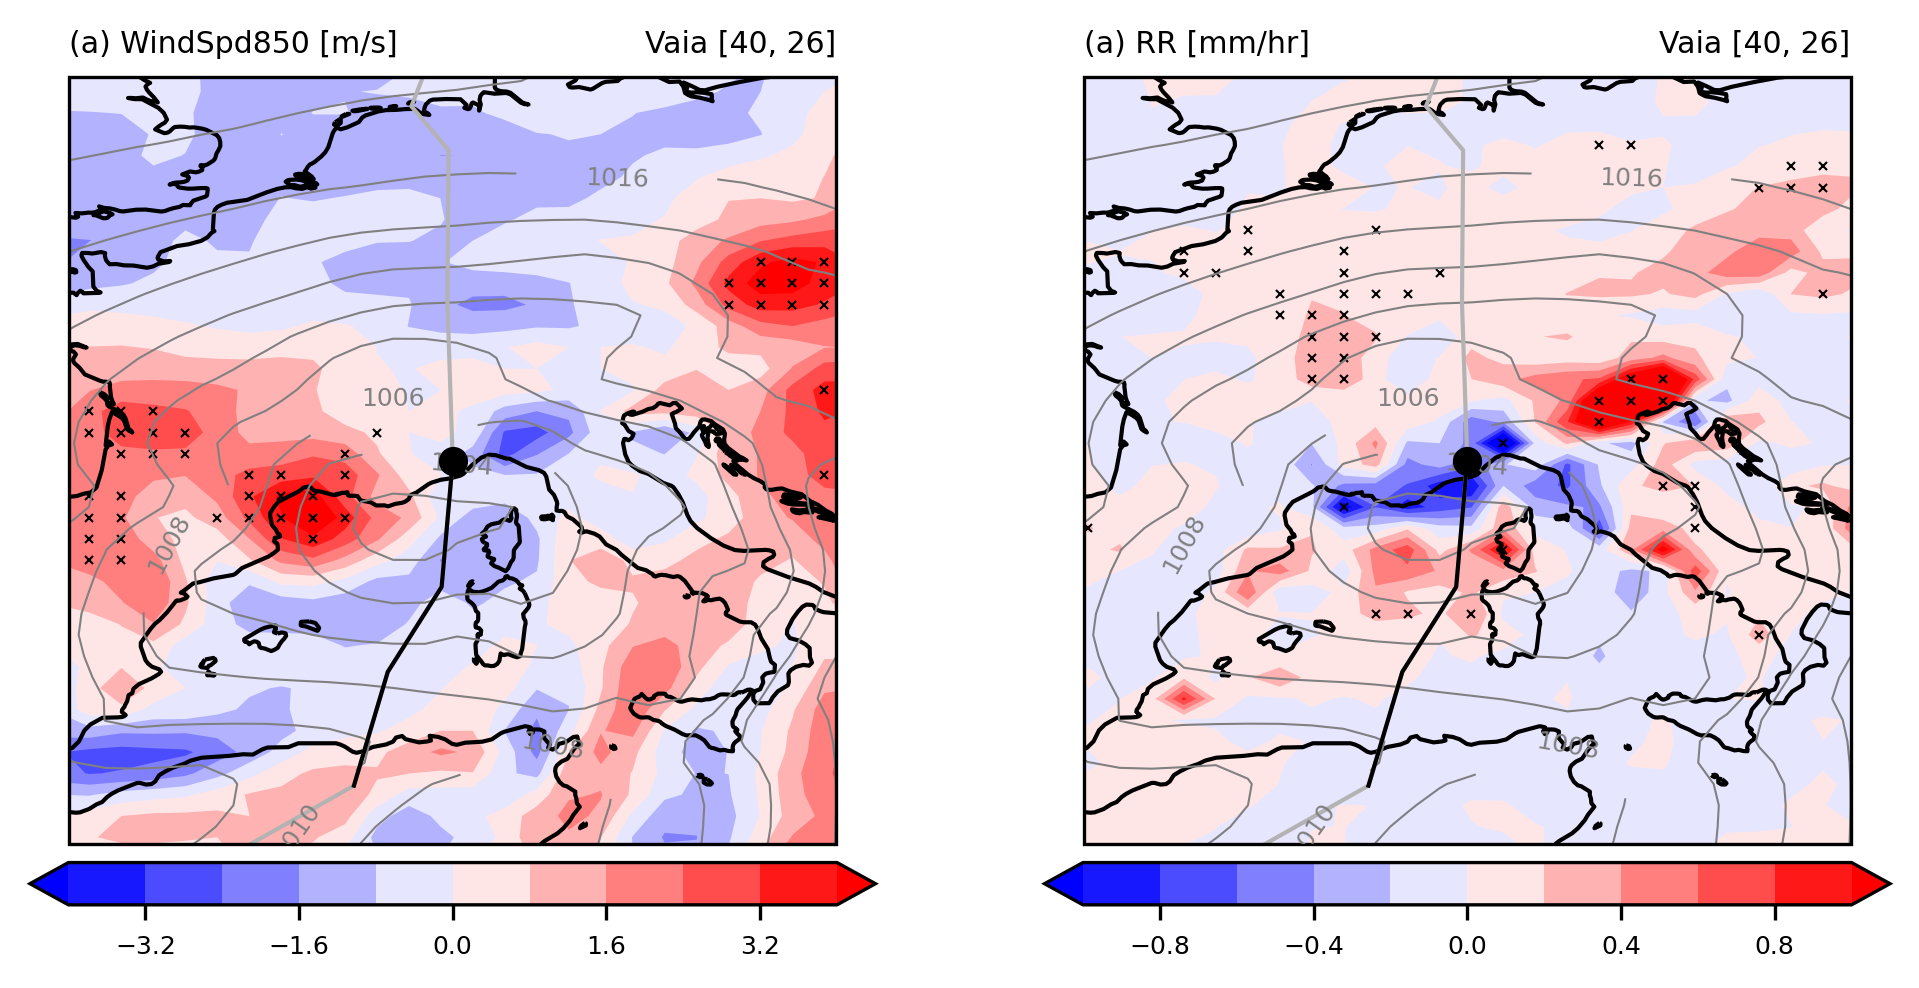

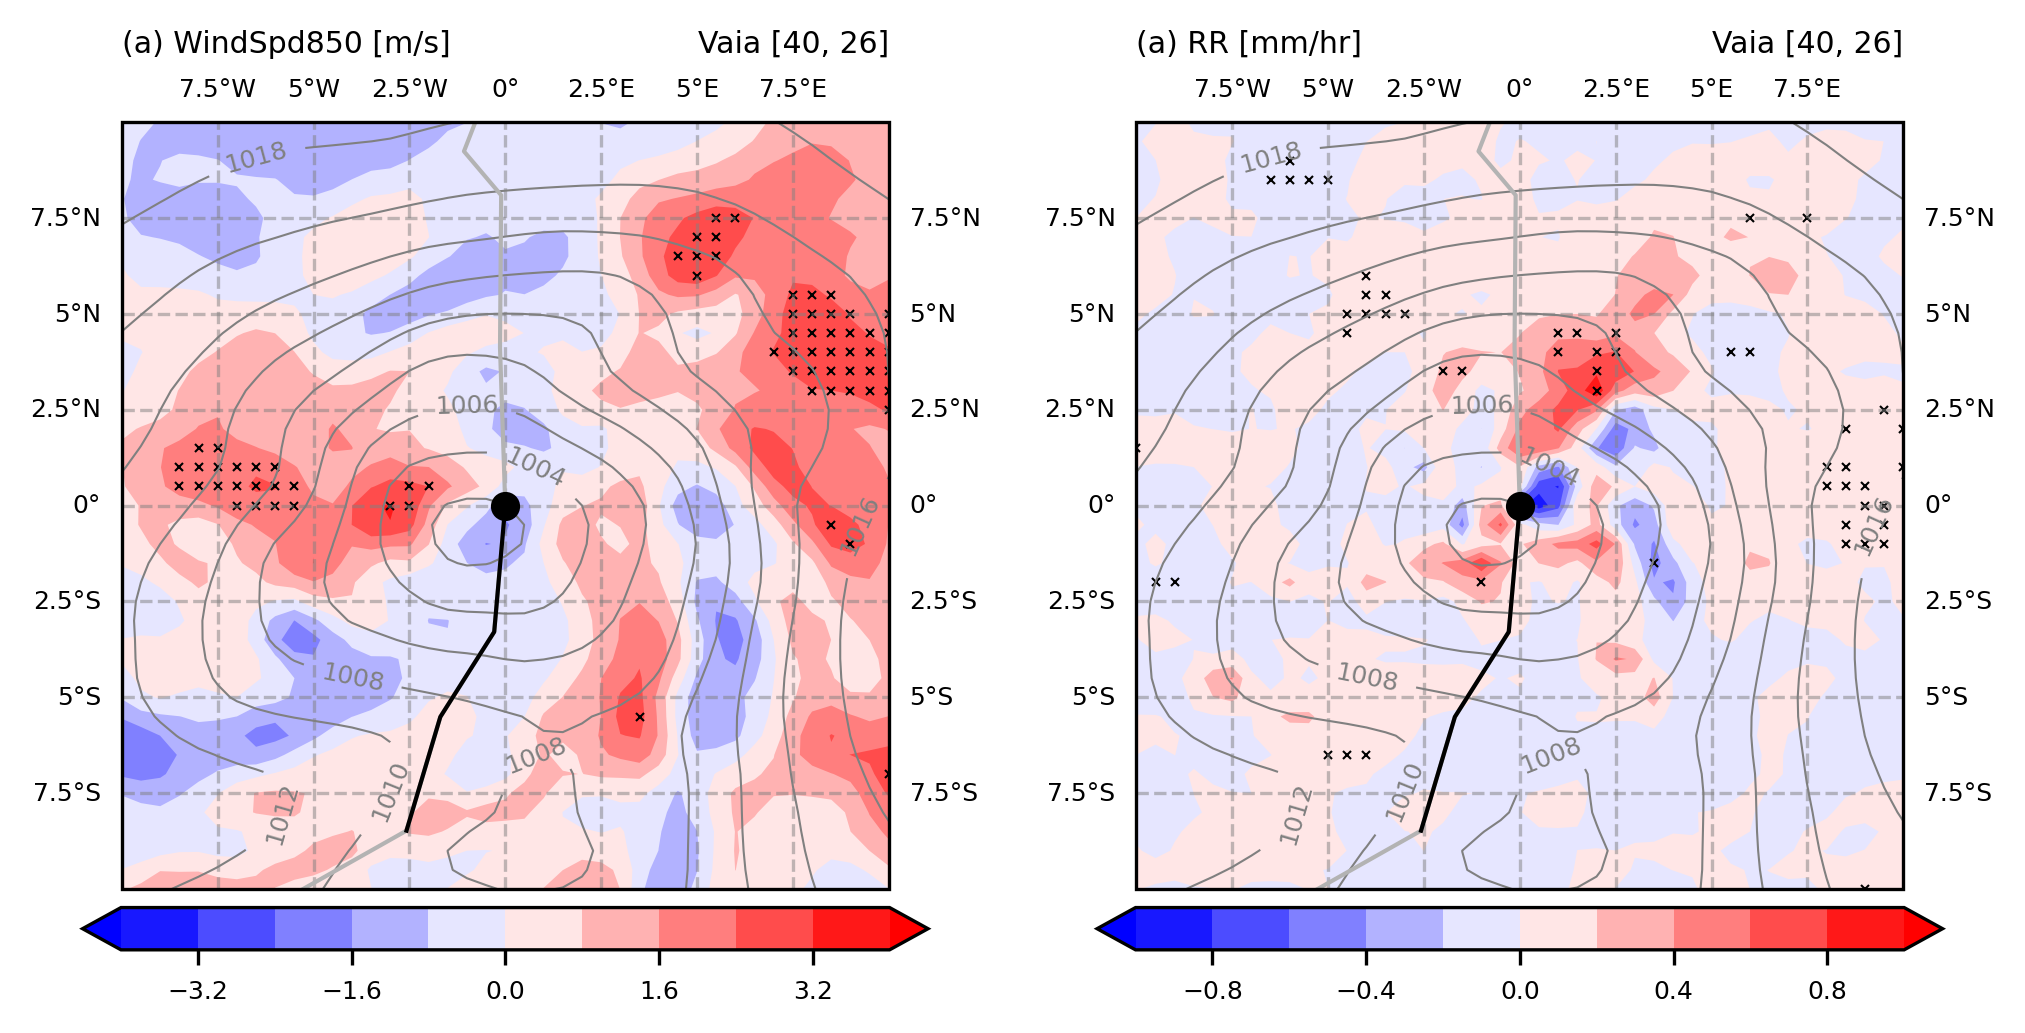

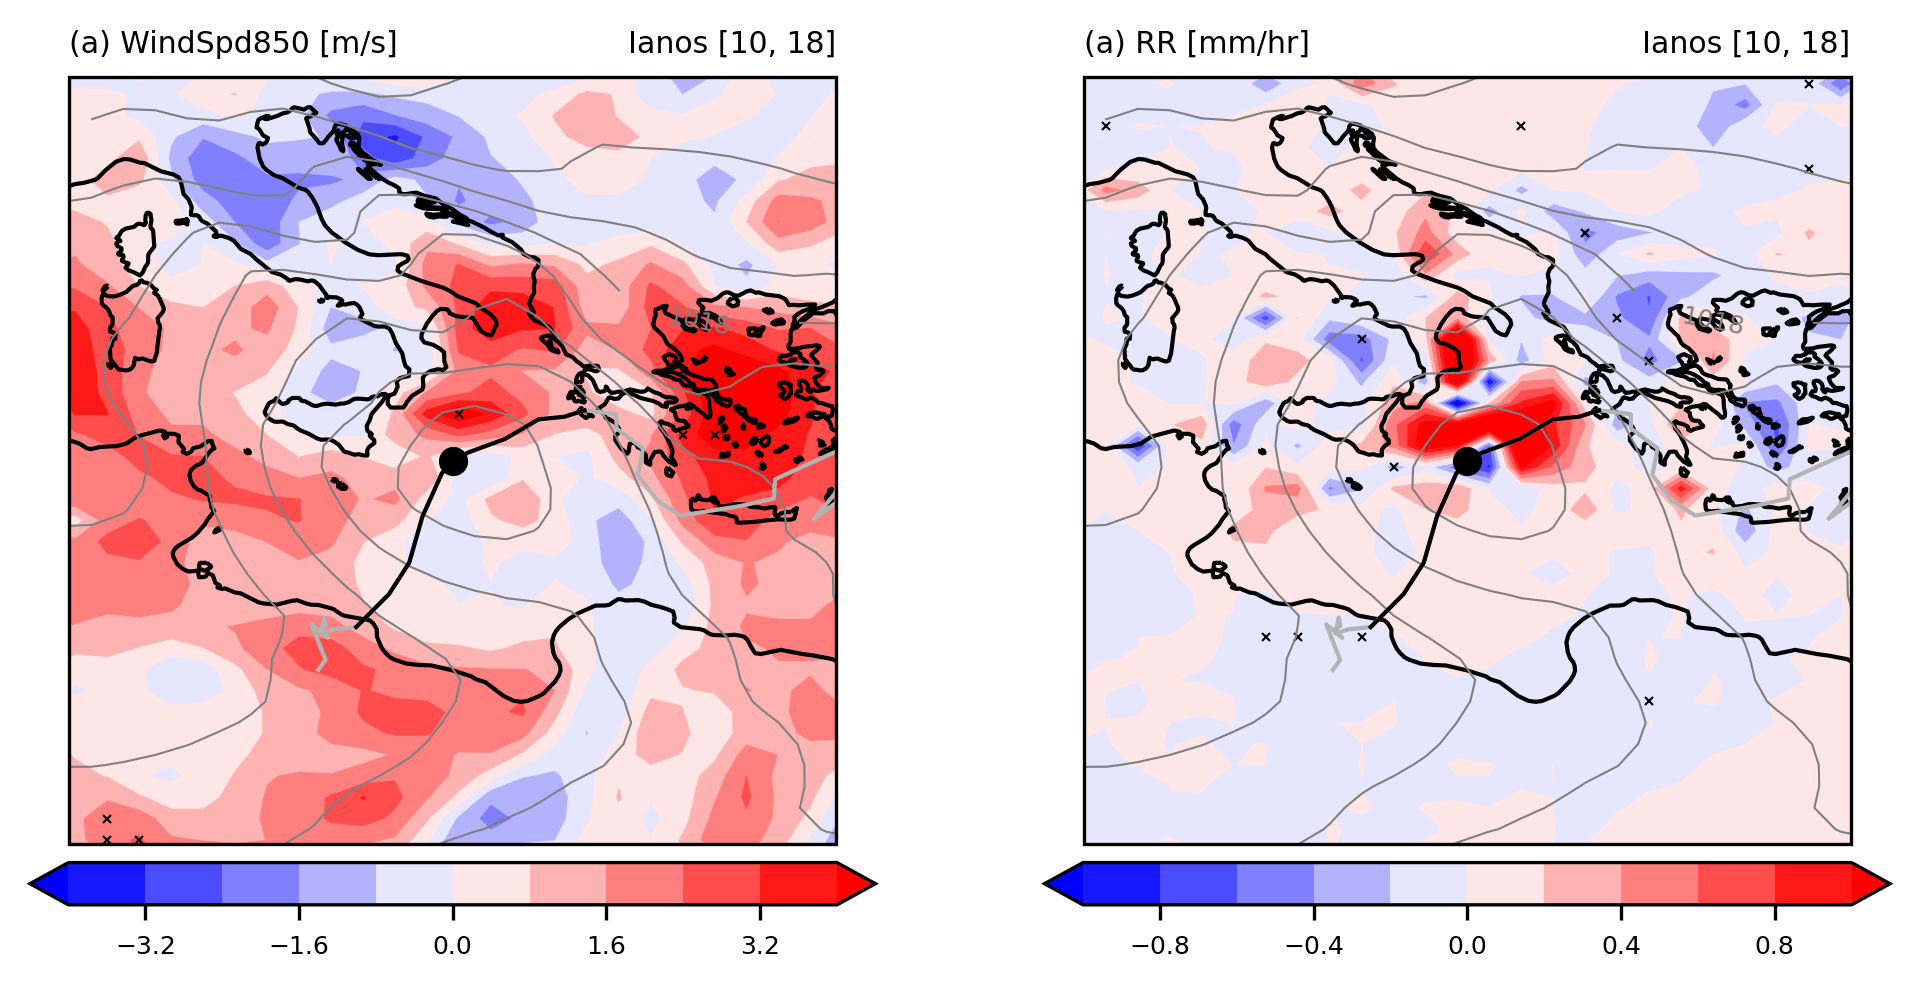

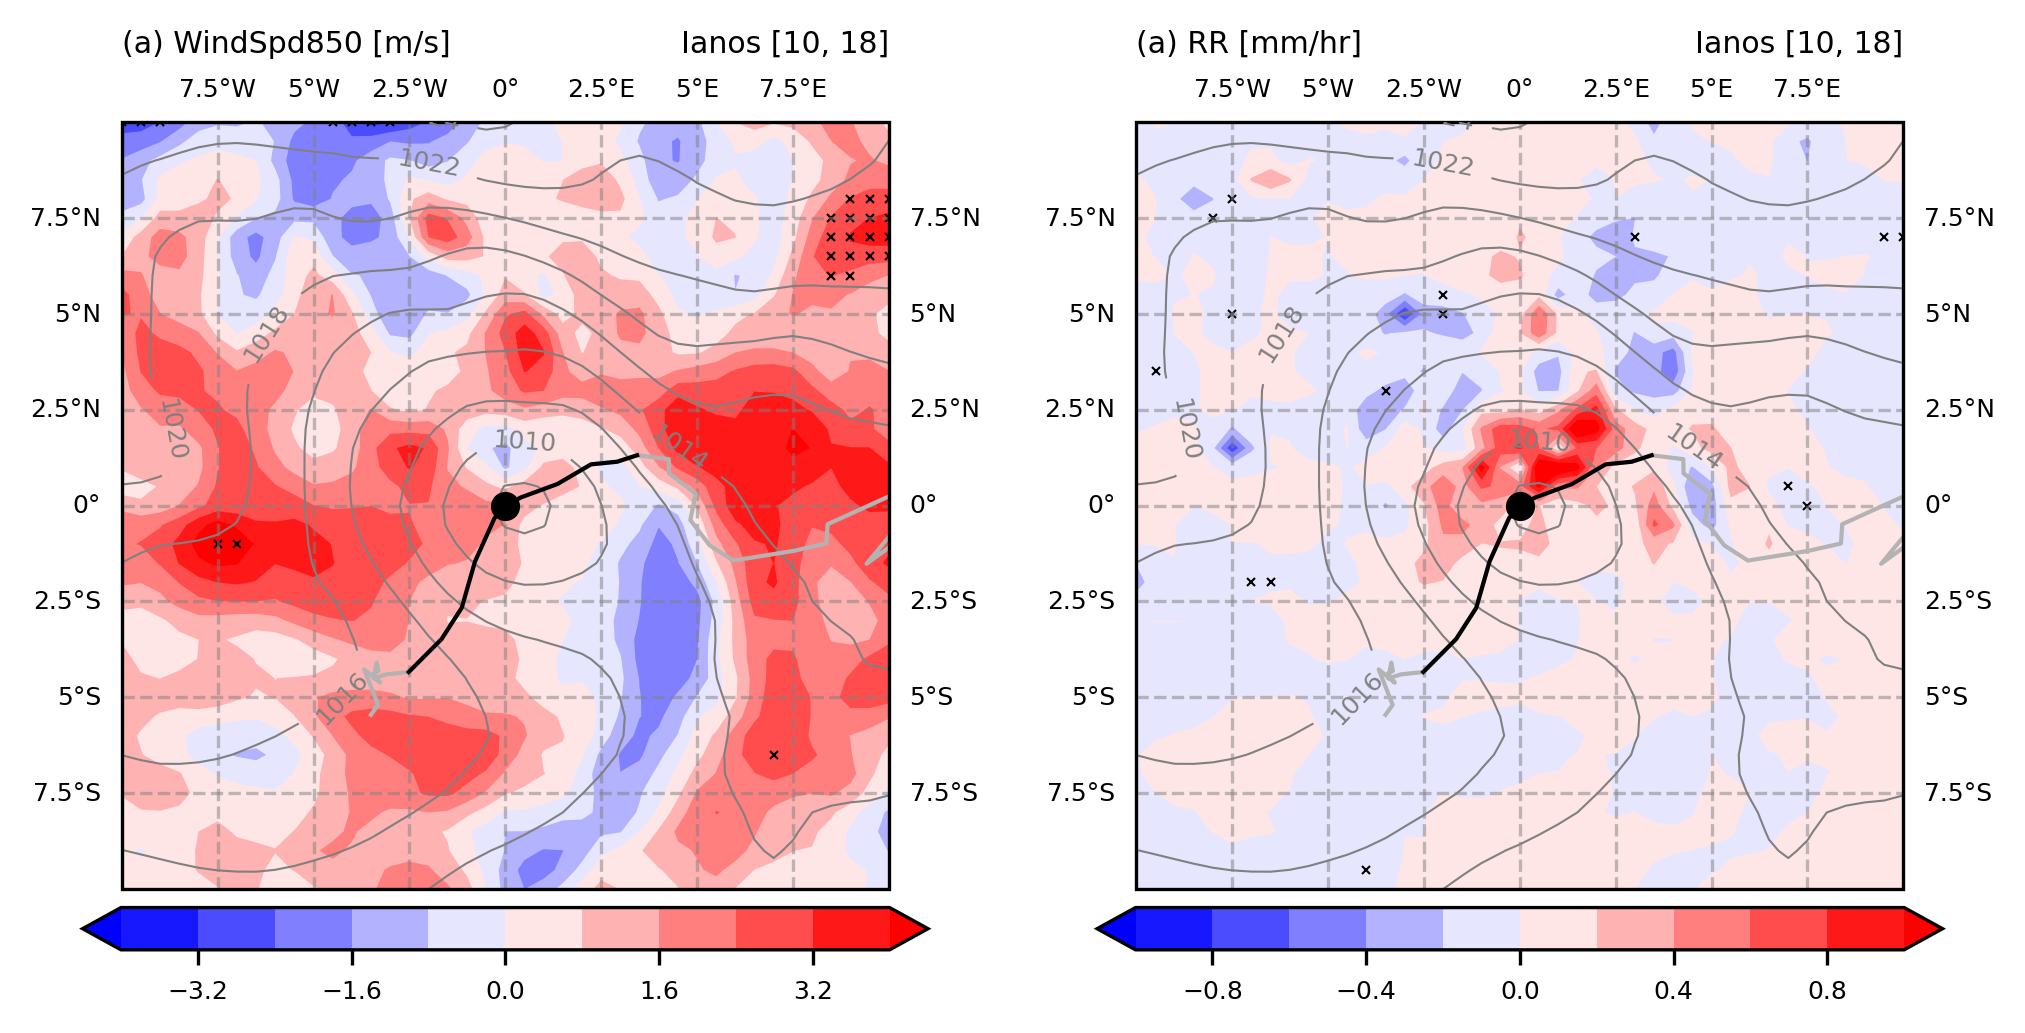

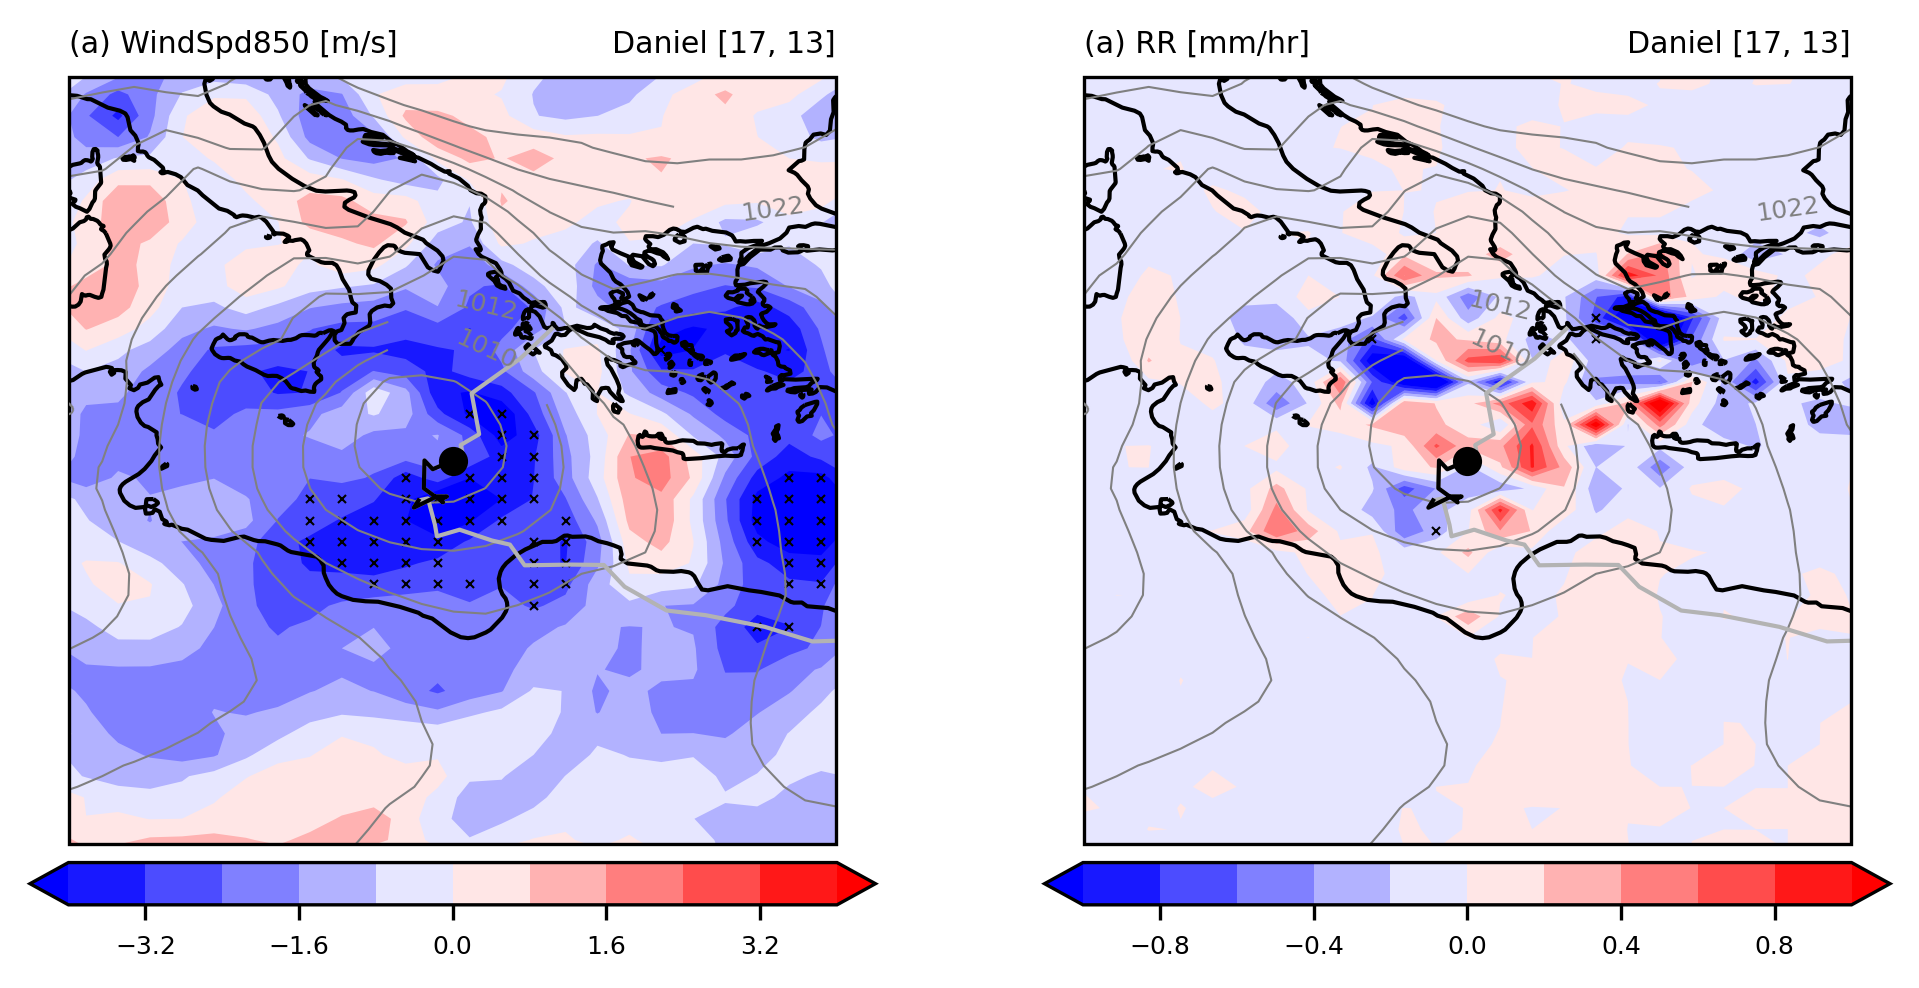

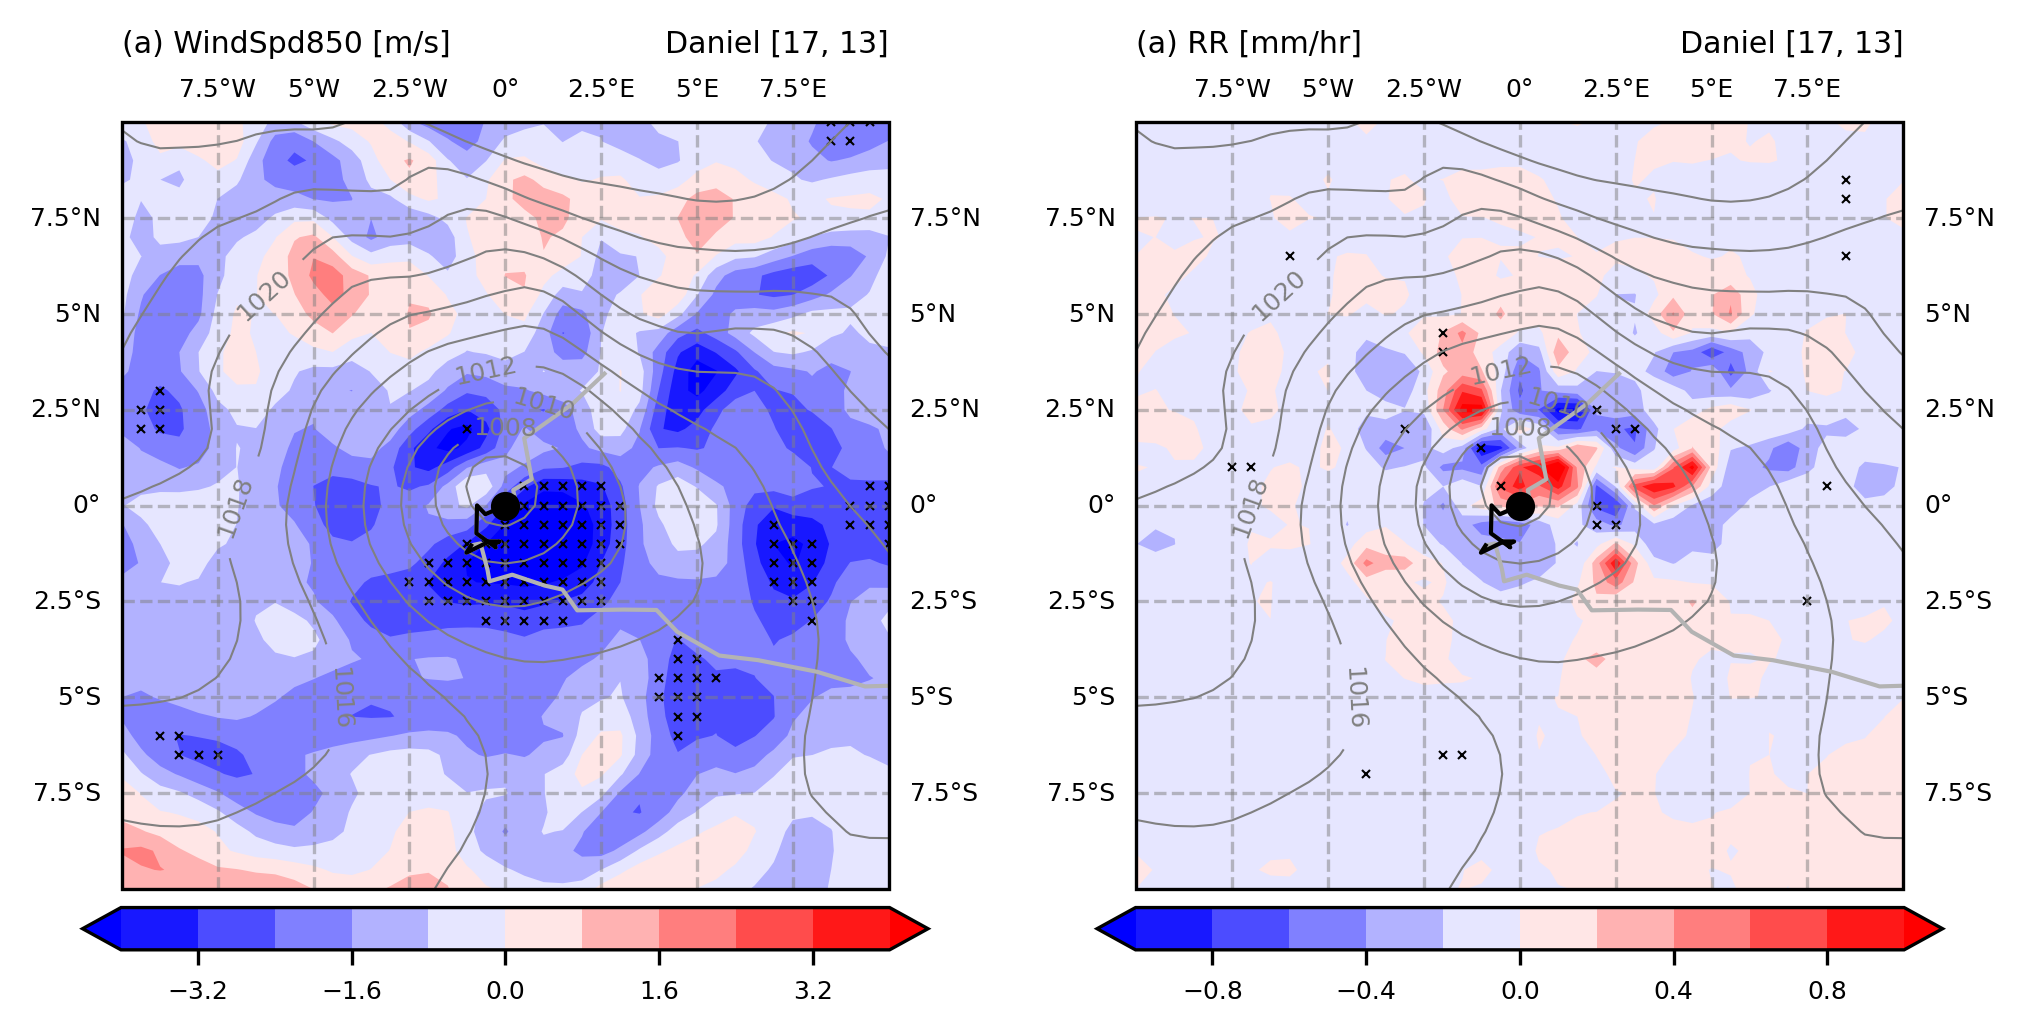

In [5]:
# Map Plots
plt.rcParams.update({'font.size': 6})


def get_centred(chis):
    chis_centred = iris.cube.CubeList()
    for i in range(len(chis.coord('time').points)):
        chis_centred.append(get_storm_centred_map(
            chis[i:i+1],
            chis.coord('track_latitude').points[i],
            chis.coord('track_longitude').points[i]
        ))
    for cube in chis_centred:
        cube.coord('grid_longitude').coord_system = None
        cube.coord('grid_latitude').coord_system = None
        cube.coord('grid_longitude').rename('longitude')
        cube.coord('grid_latitude').rename('latitude')
    return chis_centred.concatenate_cube()


def plot_spatial_composite(case, var, cubesh, cubesf, ax=None, size=10, centred=False):
    print(f'\nPLOT_SPATIAL_COMPOSITE: {case} {var} {'(centred)' if centred else ''}')
    proj = ccrs.PlateCarree()
    pglobal = 0.1 # For FDR test
    plocal = 0.05 # For local test
    
    # Get target track
    target_track = load_single_era5_track(
        cases[case]['date'],
        cases[case]['trackid'],
        trackvar=cases[case]['trackvar']
    )
    segment = _get_track_segment(target_track, **settings[setting])
    target_lon, target_lat = [l[settings[setting]['seg_len_before']] for l in _get_lonslats(segment)]
    if not centred:
        extent = [target_lon-size, target_lon+size, target_lat-size, target_lat+size]
    else:
        extent = [-size, size, -size, size]
    # Get number of composite fields
    nh = len(cubesh[0].coords('time')[0].points)
    nf = len(cubesf[0].coords('time')[0].points)
    # Set levels etc
    conlevs = {'wind_speed': np.linspace(-4, 4, 11),
              'precipitation_flux': np.linspace(-1, 1, 11)}[var]
    title = {'wind_speed': 'WindSpd850 [m/s]',
             'precipitation_flux': 'RR [mm/hr]'}[var]

    # Setup plot
    if ax is None:
        fig, axs = plt.subplots(1, 1, figsize=[4, 4], dpi=300,
                                subplot_kw={'projection': ccrs.PlateCarree()})

    # Do plotting
    chis = cubesh.extract_cube(var)
    cfut = cubesf.extract_cube(var)
    if centred:
        chis = get_centred(chis)
        cfut = get_centred(cfut)

    fill = (cfut.collapsed('time', iris.analysis.MEAN) - chis.collapsed('time', iris.analysis.MEAN))
    con = chis.collapsed('time', iris.analysis.MEAN)
    cf = iplt.contourf(fill, axes=ax, cmap='bwr', levels=conlevs, extend='both')
    ax.set_title(f'(a) {title}', loc='left')
    ax.set_title(f'{case} [{nh}, {nf}]', loc='right')
    plt.colorbar(cf, ax=ax, orientation='horizontal', pad=0.02)

    # Add stippling
    pvals = scipy.stats.ttest_ind(chis.data, cfut.data, axis=0).pvalue
    lon2d, lat2d = np.meshgrid(chis.coord('longitude').points, chis.coord('latitude').points)
    pcube_subset = con.copy(data=pvals).intersection(longitude=extent[:2], latitude=extent[2:])
    pvals_subset = pcube_subset.data
    sorted_pvals = np.sort(pvals_subset[~np.isnan(pvals_subset)])
    N = len(sorted_pvals)
    mask = sorted_pvals < np.arange(1, N+1) * pglobal / N
    if np.any(mask):
        plocal_FDR = sorted_pvals[np.where(mask)[0][-1]]
    else:
        plocal_FDR = 0.0
    print(f'Nall={pvals_subset.shape[0]*pvals_subset.shape[1]}, ' \
          f'Nfinite={N}, pglobal={pglobal}, pFDR={plocal_FDR}')

    sig = np.isfinite(pvals) & (pvals < plocal)
    sig_fdr = np.isfinite(pvals) & (pvals < plocal_FDR)

    # Significance crosses
    ax.plot(
        lon2d[sig & ~sig_fdr], lat2d[sig & ~sig_fdr], 'x',
        mfc='k',
        mec='k',
        ms=2,
        mew=0.5,
        transform=proj,
        zorder=1,
    )

    # FDR significance circles
    ax.plot(
        lon2d[sig_fdr], lat2d[sig_fdr], 'o',
        mfc='k',
        mec='k',
        ms=2,
        mew=0.5,
        transform=proj,
        zorder=1,
    )

    mslp = cubesh.extract_cube('air_pressure_at_sea_level')
    if centred:
        mslp = get_centred(mslp)
    cc = iplt.contour(mslp.collapsed('time', iris.analysis.MEAN), axes=ax, colors='0.5', levels=np.arange(900, 1100, 2),
                      linewidths=0.5)
    plt.clabel(cc)
    if not centred:
        ax.coastlines()
        ax.plot(target_lon, target_lat, transform=proj, color='k', marker='o', zorder=100)
    else:
        ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
        ax.plot(0, 0, transform=proj, color='k', marker='o', zorder=100)
        target_track['longitude'].values -= target_lon
        target_track['latitude'].values -= target_lat
        segment['longitude'].values -= target_lon
        segment['latitude'].values -= target_lat
    plot_tracks({1: target_track}, ax=ax, color='0.7', show_intensity=False)
    ax = plot_tracks({1: segment}, ax=ax, color='black', show_intensity=False, label=case)
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    return ax.figure, ax


for case, setting in zip(cases_to_use, settings_to_use):
    # Check have analogues availabile for hist and future
    if cubesh[case] is None or cubesf[case] is None:
        print(f'\nAnalogues not available for {case}: Skipping')
        continue
    
    # Geographical
    fig, axs = plt.subplots(1, 2, figsize=[8, 4], dpi=300,
                            subplot_kw={'projection': ccrs.PlateCarree()})
    plot_spatial_composite(case, 'wind_speed', cubesh[case], cubesf[case], ax=axs[0], size=10)
    plot_spatial_composite(case, 'precipitation_flux', cubesh[case], cubesf[case], ax=axs[1], size=10)
    fig.figure.savefig(plot_dir / f'{case}_{setting}_composites-all.png')
    
    # Centred
    fig, axs = plt.subplots(1, 2, figsize=[8, 4], dpi=300,
                            subplot_kw={'projection': ccrs.PlateCarree()})
    plot_spatial_composite(case, 'wind_speed', cubesh[case], cubesf[case], ax=axs[0], size=10, centred=True)
    plot_spatial_composite(case, 'precipitation_flux', cubesh[case], cubesf[case], ax=axs[1], size=10, centred=True)
    fig.figure.savefig(plot_dir / f'{case}_{setting}_centredcomposites-all.png')